### ✅ 테스트 1~4 실행 결과

#### 테스트 1: 인증 실행 결과
인증 테스트 결과, 예상대로 인증이 작동함을 확인했습니다. API 키가 없거나 잘못된 키를 사용한 요청은 HTTP 401 Unauthorized 에러를 반환했으며, 올바른 키를 사용한 요청은 HTTP 200 OK 상태와 함께 정상적인 봇 응답을 받았습니다. 이는 API Key 기반 인증 시스템이 제대로 구현되었음을 보여줍니다.

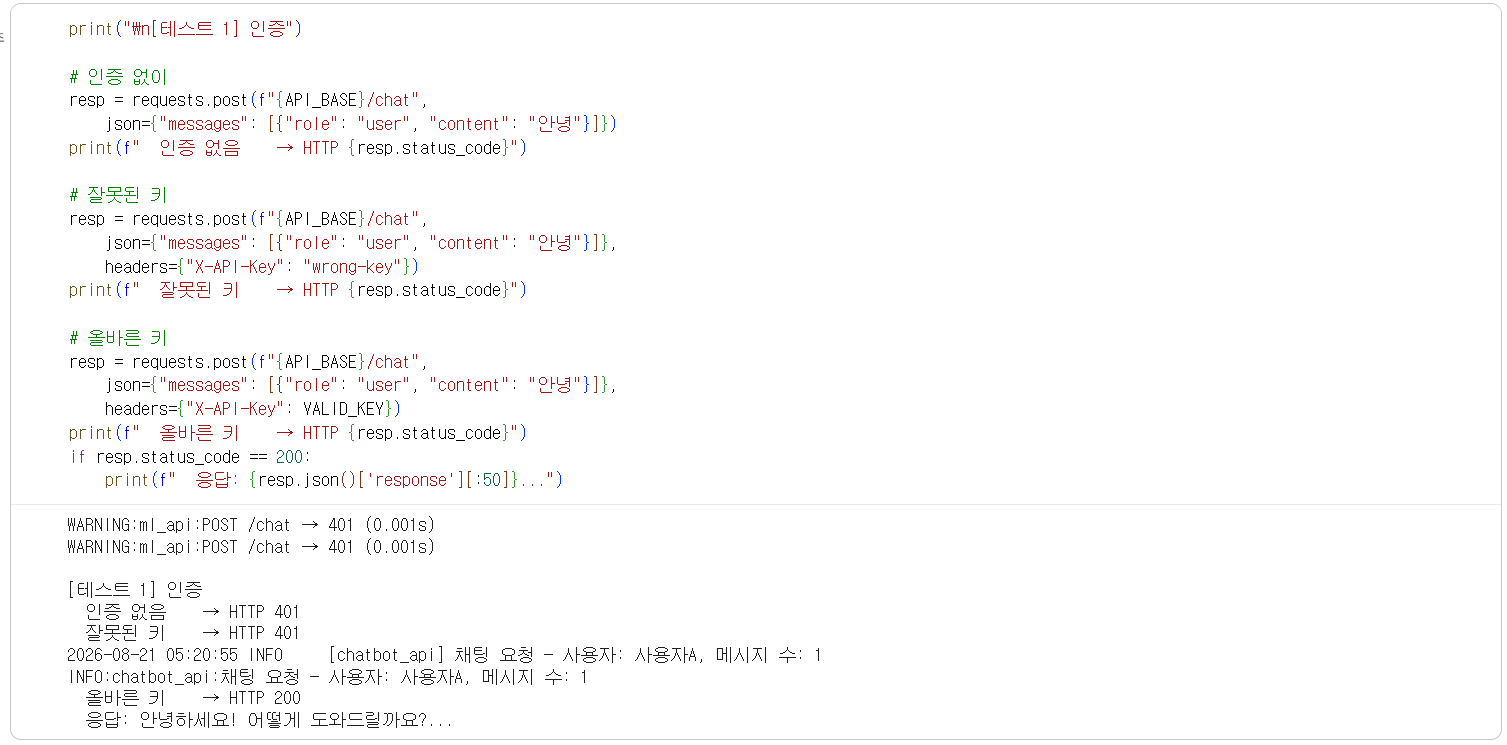

#### 테스트 2: 멀티턴 대화 실행 결과
멀티턴 대화 테스트는 성공적으로 완료되었습니다. 챗봇이 사용자의 이전 메시지를 기억하고 맥락에 맞는 응답을 생성하는 것을 확인했습니다. 각 턴마다 이전 대화 기록을 포함하여 API에 전송함으로써 멀티턴 대화 기능이 정상적으로 구현되었음을 알 수 있습니다.

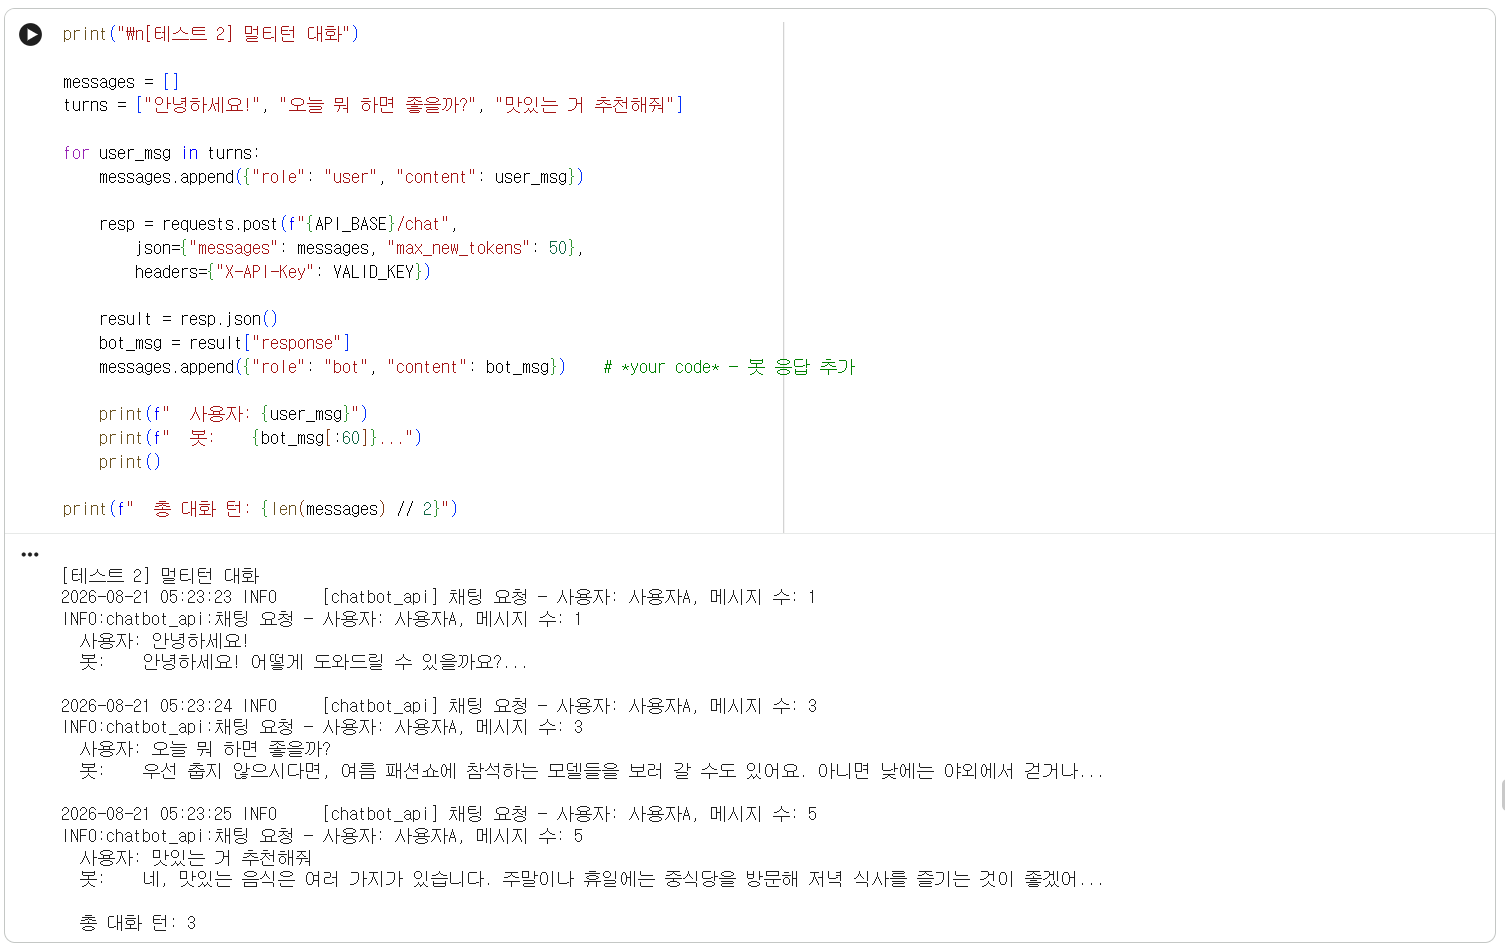

#### 테스트 3: 입력 검증 실행 결과
입력 검증 테스트 결과, API 스키마에 정의된 유효성 검사가 잘 작동함을 확인했습니다. 빈 메시지 목록이나 `temperature` 파라미터가 유효 범위를 초과하는 경우 모두 HTTP 422 Unprocessable Entity 에러가 반환되었습니다. 이는 잘못된 입력으로부터 서버를 보호하는 데 필수적인 요소입니다.

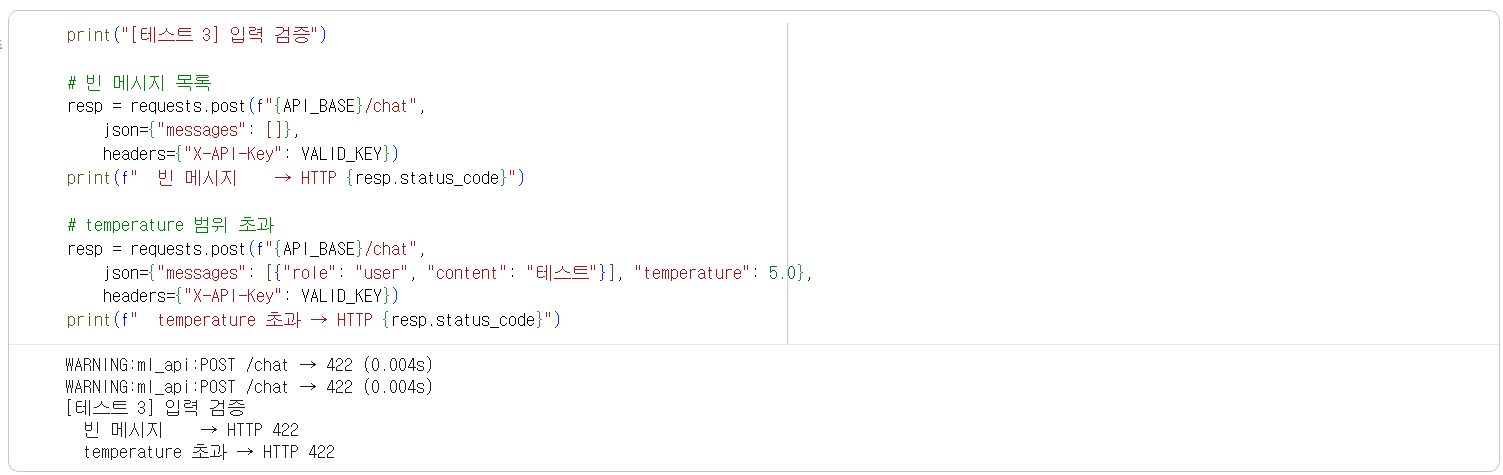

#### 테스트 4: 동시 요청 실행 결과
동시 요청 테스트는 성공적으로 실행되었습니다. 4개의 동시 요청 모두 HTTP 200 OK 상태를 반환했으며, 총 실행 시간은 개별 요청 시간을 합한 것보다 훨씬 짧게 측정되어 비동기 처리가 효과적으로 이루어지고 있음을 보여줍니다. 이는 다중 사용자가 동시에 서비스를 이용할 때 안정적인 응답을 제공할 수 있음을 의미합니다.

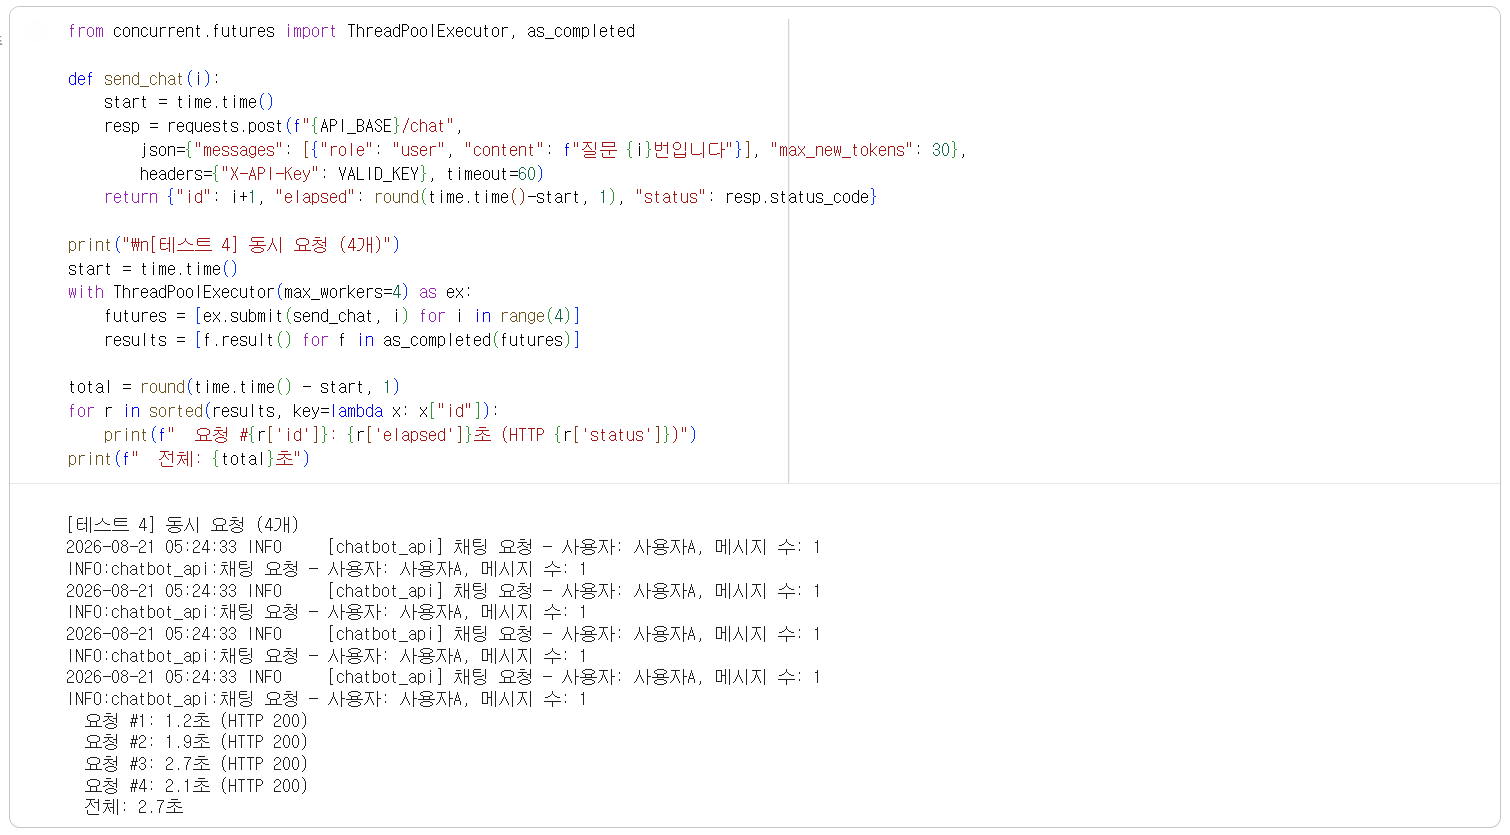

### ✅ UI 테스트 실행결과

[테스트 A] 기본 대화
  1. 사이드바에 API Key 입력
  2. "안녕하세요" 입력 → 봇 응답 확인
  3. 추가 메시지 입력 → 멀티턴 대화 확인

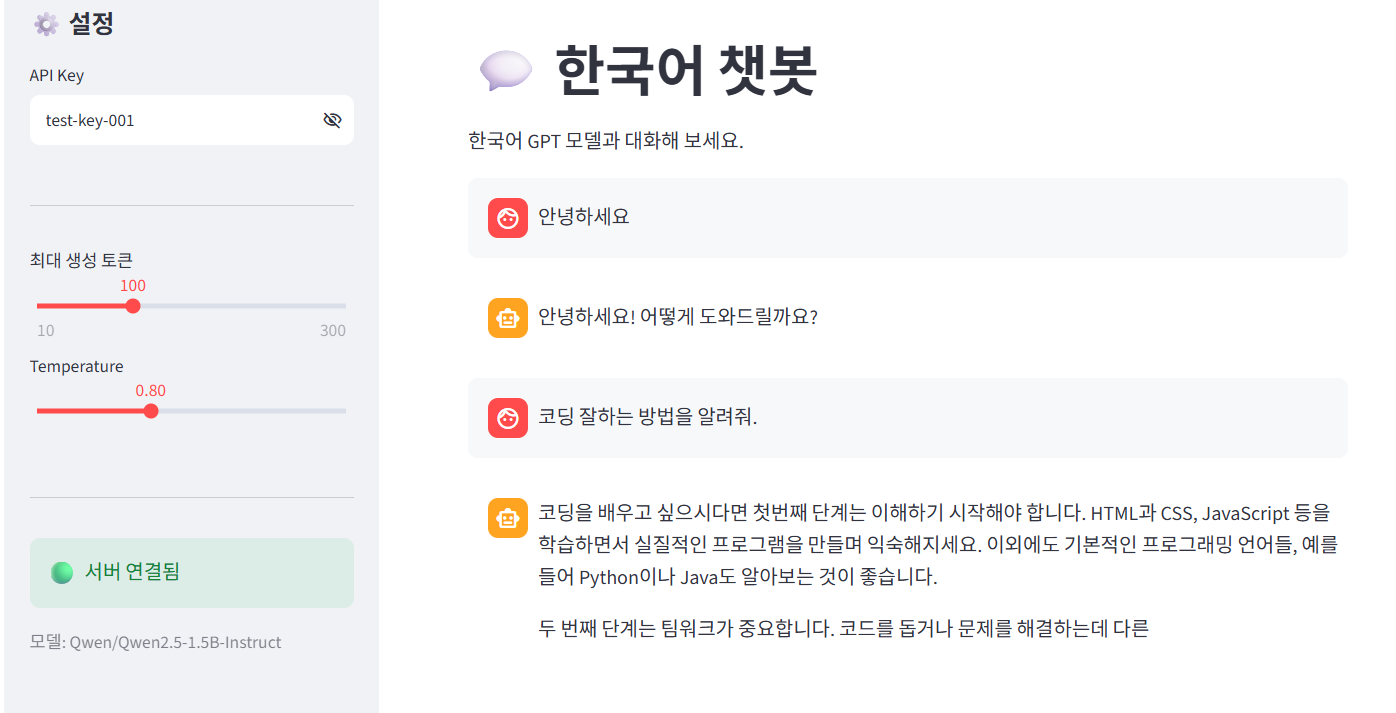

[테스트 B] 설정 변경
  1. Temperature를 0.1로 낮추기 → 보수적인 응답 확인
  2. Temperature를 1.5로 올리기 → 다양한 응답 확인

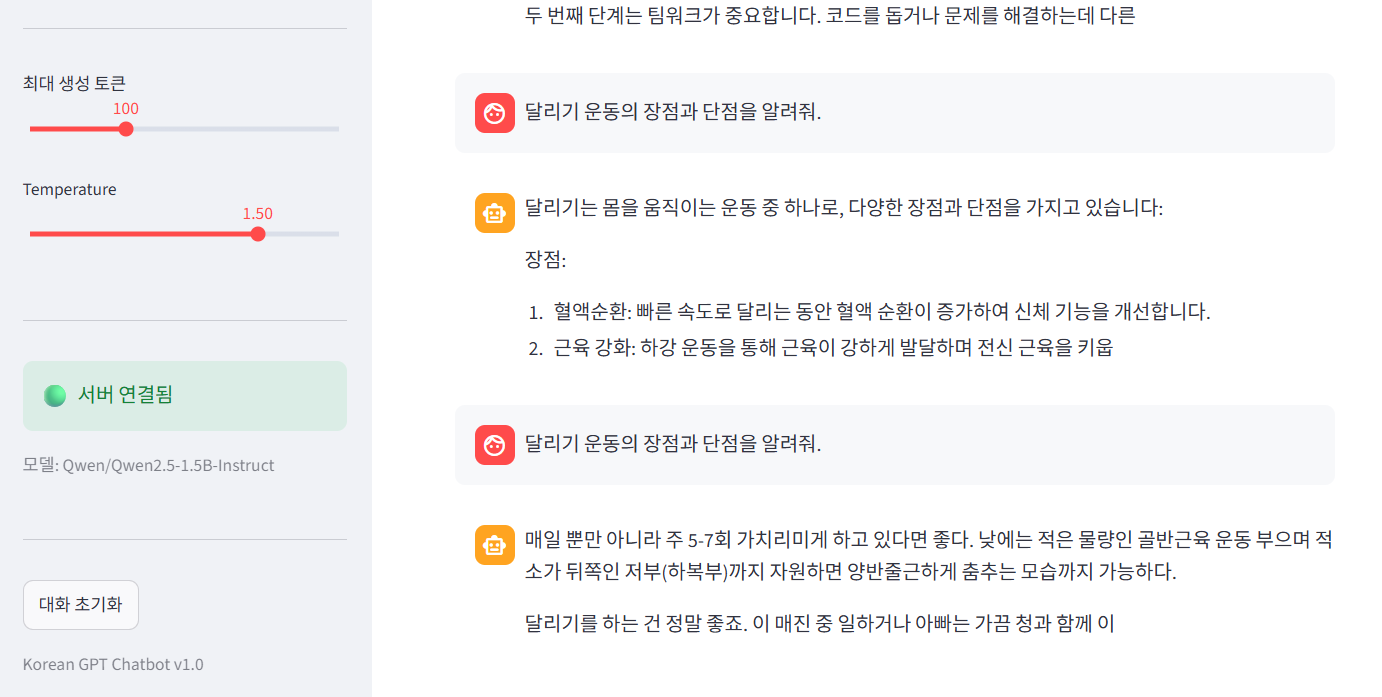

[테스트 C] 대화 초기화
  1. 여러 턴 대화 후 "대화 초기화" 클릭
  2. 대화 기록이 사라지는지 확인
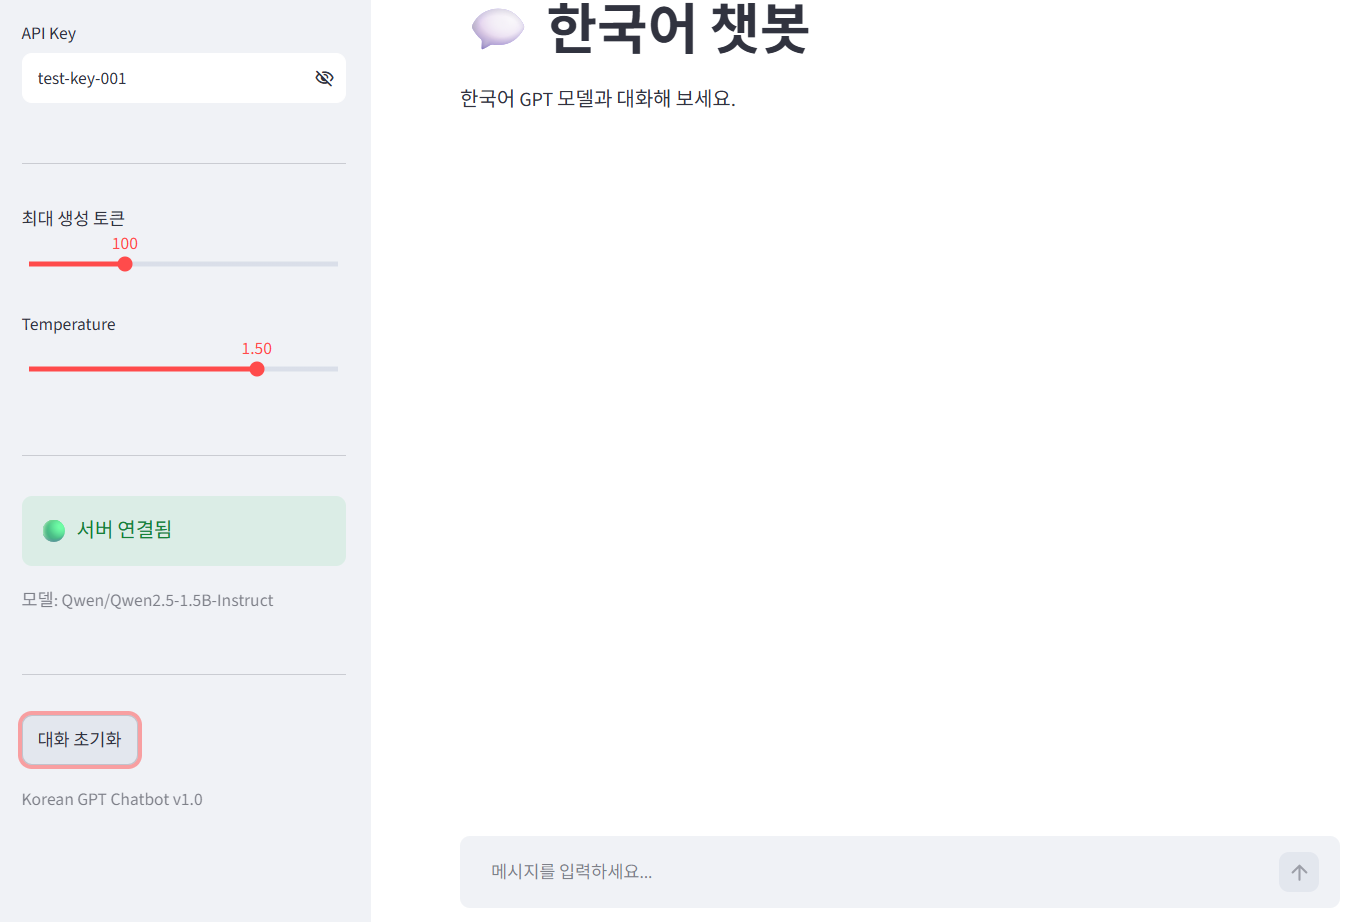

[테스트 D] 인증 실패
  1. API Key를 wrong-key로 변경
  2. 메시지 입력 → "🔑 인증 실패" 메시지 확인
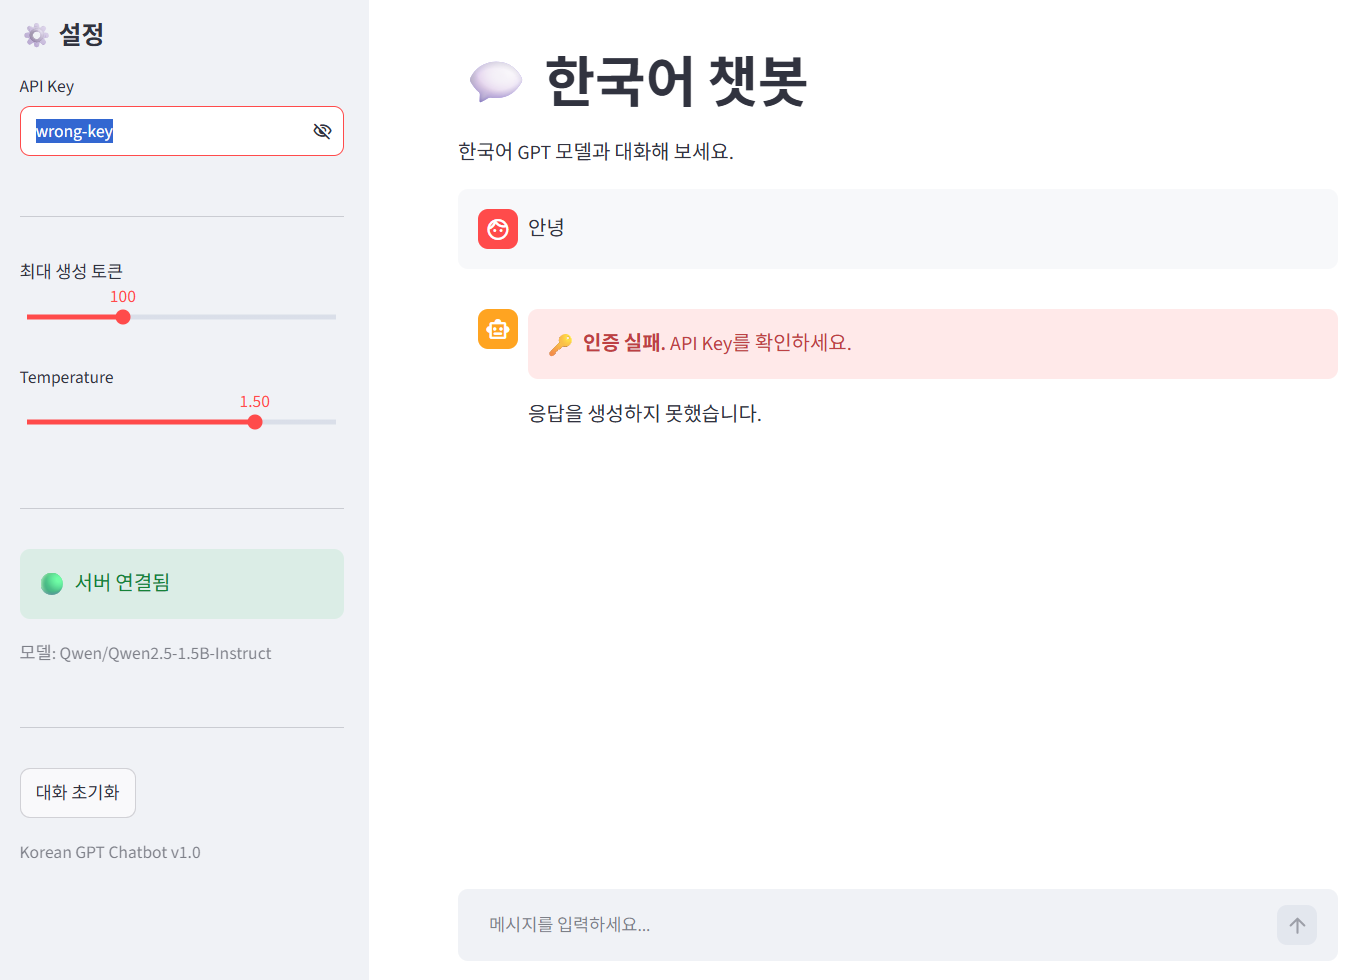

### ✅ 체크포인트 01


1.  **Day 5 (정형 데이터)와 Day 7 (텍스트 생성)에서 전처리가 어떻게 다릅니까?**
    *   **Day 5 (정형 데이터):** 숫자 및 범주형 데이터의 결측치 처리, 스케일 조정, 인코딩 등 구조화된 데이터 변환에 집중합니다.
    *   **Day 7 (텍스트 생성):** 텍스트 데이터를 언어 모델이 이해할 수 있는 토큰 단위로 분리하고, 특별 토큰 추가 및 숫자 시퀀스로 변환하는 작업에 집중합니다.

2.  **Hugging Face Transformers 라이브러리의 역할은 무엇입니까?**
    *   다양한 사전 학습된 언어 모델(LLMs)과 이를 활용하기 위한 토크나이저 등 도구를 제공하여, 텍스트 분류, 번역, 생성 등의 작업을 쉽게 수행할 수 있도록 지원합니다.

### ✅ 체크포인트 02


1.  **토크나이저의 `encode()`와 `decode()`는 각각 어떤 변환을 수행합니까?**
    *   `encode()`: 텍스트 문장을 모델이 처리할 수 있는 숫자(토큰 ID) 시퀀스로 변환합니다.
    *   `decode()`: 숫자(토큰 ID) 시퀀스를 사람이 읽을 수 있는 텍스트 문장으로 다시 변환합니다.

2.  **`model.generate()`의 `temperature` 파라미터는 생성 결과에 어떤 영향을 줍니까?**
    *   `temperature`는 생성 텍스트의 다양성과 창의성을 조절합니다. 값이 낮으면 예측 가능하고 일관된 답변을, 값이 높으면 다양하고 창의적인 답변을 생성하는 경향이 있습니다.

3.  **멀티턴 대화에서 이전 대화 기록을 프롬프트에 포함하는 이유는 무엇입니까?**
    *   모델이 대화의 맥락을 이해하고 일관성 있는 답변을 생성할 수 있도록 하기 위함입니다. LLM은 자체적으로 이전 대화를 기억하지 못하므로, 매번 전체 기록을 제공해야 합니다.

### ✅ 체크포인트 03


1.  **`ChatRequest`의 `messages`가 리스트인 이유는 무엇입니까?**
    *   대화가 여러 번 주고받는 메시지들로 구성된 시퀀스이기 때문입니다. 각 턴의 메시지를 순서대로 담아 모델에 전달합니다.

2.  **서버가 대화 기록을 저장하지 않고, 클라이언트가 매번 전체 기록을 보내는 이유는?**
    *   '상태 비저장(Stateless)' 원칙을 따라 서버 부하를 줄이고 확장성을 높이기 위함입니다. 클라이언트가 대화 기록을 관리하여 서버는 각 요청을 독립적으로 처리합니다.

3.  **`max_new_tokens`을 너무 크게 설정하면 어떤 문제가 발생할 수 있습니까?**
    *   불필요한 비용 증가, 응답 시간 증가, 메모리 사용량 증가, 그리고 비논리적이고 장황한 답변이 생성될 수 있습니다.

### ✅ 체크포인트 04



1.  **`st.chat_message`와 `st.chat_input`은 각각 어떤 역할을 합니까?**
    *   `st.chat_message`: 챗봇 UI에서 사용자 또는 어시스턴트의 대화 메시지를 표시합니다.
    *   `st.chat_input`: 사용자가 메시지를 입력할 수 있는 입력창을 생성합니다.

2.  **`st.session_state["chat_messages"]`에 대화 기록을 저장하는 이유는?**
    *   Streamlit 앱은 재실행 시 변수값이 초기화되므로, `st.session_state`를 사용하여 앱의 상태(대화 기록)를 유지하고 이전 대화 내용을 보존하기 위함입니다.

3.  **"대화 초기화" 버튼이 `st.rerun()`을 호출하는 이유는 무엇입니까?**
    *   `st.session_state["chat_messages"]`를 지운 후 `st.rerun()`을 호출하여 Streamlit 앱을 처음부터 다시 실행시켜 화면에 표시된 대화 내용을 완전히 초기화하기 위함입니다.

### ✅ 체크포인트 05


1.  **챗봇 API에서 인증이 실패하면 서버는 어떤 상태 코드를 반환합니까?**
    *   일반적으로 `401 Unauthorized` 상태 코드를 반환하여, 유효한 인증 자격 증명이 없음을 알립니다.

2.  **UI의 `call_chat_api()`는 401 응답을 받으면 사용자에게 무엇을 보여줍니까?**
    *   `st.error()`를 사용하여 'API Key가 유효하지 않습니다.'와 같은 오류 메시지를 표시하고, 사용자에게 올바른 API 키 입력을 유도합니다.

3.  **Day 6의 인증 모듈(`app/auth.py`)을 Day 7에서 수정 없이 재사용할 수 있는 이유는 무엇입니까?**
    *   인증 모듈이 '분리된 관심사(Separation of Concerns)' 원칙에 따라 독립적으로 구현되어, 인증 로직이 다른 기능과 분리되어 있기 때문입니다.

### ✅ Day 7 최종 체크포인트




**Q1. Day 5(정형 데이터)와 Day 7(텍스트 생성)에서 전처리 방식의 차이는?**

*   **Day 5 (정형 데이터):** 숫자 및 범주형 데이터의 정제 및 구조화된 변환에 중점을 둡니다.
*   **Day 7 (텍스트 생성):** 텍스트를 언어 모델이 이해하도록 토큰화하고 숫자 시퀀스로 변환하는 작업에 중점을 둡니다.

**Q2. 멀티턴 대화에서 서버가 상태를 유지하지 않는 이유는?**

*   서버의 부하를 줄이고 확장성을 확보하기 위해 '상태 비저장(Stateless)' 원칙을 따릅니다. 클라이언트가 대화 기록을 관리하고 서버는 각 요청을 독립적으로 처리합니다.

**Q3. API Key가 잘못되면 서버는 어떤 상태 코드를 반환하고, UI는 어떻게 처리합니까?**

*   서버는 `401 Unauthorized` 상태 코드를 반환하며, UI는 'API Key가 유효하지 않습니다.'와 같은 오류 메시지를 표시합니다.

**Q4. temperature를 낮추면 생성 결과에 어떤 변화가 있습니까?**

*   생성 텍스트의 다양성이 줄어들고, 더 예측 가능하며 일관성 있고 반복적인 답변이 생성되는 경향이 있습니다.

**Q5. 이 서비스를 다른 컴퓨터에서 실행하려면 무엇이 필요합니까?**

*   소스 코드, 필요한 라이브러리 설치 (예: `requirements.txt` 사용), Python 버전 일치, 그리고 API Key와 같은 환경 변수 설정이 필요합니다.

### 📌 회고

#### □ 시도해 보고 배운 점

- 이번 학습을 통해 Hugging Face 트랜스포머 모델을 FastAPI를 이용한 백엔드 API로 서빙하고, Streamlit으로 프론트엔드 UI를 구축하는 전반적인 과정을 경험했습니다.
- 특히 멀티턴 대화 처리 로직과 API Key 인증 방식에 대해 깊이 이해할 수 있었습니다.
- `uvicorn`을 이용한 서버 관리, `pydantic` 스키마를 통한 요청/응답 검증, `asyncio`와 `ThreadPoolExecutor`를 활용한 비동기 추론 처리 등 실제 서비스 개발에 필요한 다양한 기술들을 직접 구현하고 테스트해본 것이 매우 유익했습니다.

#### □ 부족한 점

- 대규모 트래픽 발생 시 모델 로딩 시간 최적화나 여러 모델 인스턴스를 관리하는 방법에 대한 심도 있는 고민은 부족했습니다.
- 또한, `temperature`나 `top_k`, `top_p` 같은 텍스트 생성 파라미터 튜닝에 대한 체계적인 접근보다는 기본적인 설정을 사용하는 데 그쳤습니다.
- 에러 처리 로직은 구현했지만, 특정 유형의 에러(예: 토큰 길이 초과 시 사용자에게 적절한 피드백 제공)에 대한 세밀한 처리는 개선의 여지가 있습니다.

#### □ 앞으로 더 공부해야 할 점

1.  **성능 최적화**: 모델 서빙 시 GPU 활용을 극대화하고, 추론 지연 시간을 줄이기 위한 배치 처리(batching)나 양자화(quantization) 기법에 대해 더 탐구해야겠습니다. 트래픽이 많을 때 여러 모델 인스턴스를 효율적으로 관리하는 방법(예: 로드 밸런싱)도 공부하고 싶습니다.
2.  **고급 텍스트 생성**: `temperature` 외의 다양한 생성 파라미터들이 모델 응답에 미치는 영향을 심층적으로 분석하고, 특정 사용 사례에 맞는 최적의 파라미터를 찾는 방법에 대해 더 학습해야겠습니다.
3.  **CI/CD 파이프라인 구축**: 모델 학습부터 배포, 모니터링까지 자동화된 파이프라인을 구축하는 MLOps 과정에 대한 이해를 높여야 할 필요성을 느꼈습니다.
4.  **보안 강화**: 현재 API Key 방식 외에 JWT(JSON Web Token) 등 더 다양한 인증/인가 메커니즘과 보안 취약점 분석 및 방어에 대해 학습하여 서비스의 안정성을 강화해야겠습니다